In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import os 

In [4]:
import pandas as pd

# Load once
df = pd.read_csv("../data/cleaned_ipl_tweets.csv")

# Sample first
df_shared = df.sample(n=50000, random_state=42)

# Save shared subset
df_shared.to_csv("../data/shared_50k_tweets.csv", index=False)
print("Saved:", len(df_shared), "rows")
print("File size:", round(df_shared.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

# Now preprocess hashtags on the sample
df_shared["hashtags"] = df_shared["hashtags"].apply(eval)
df_shared["hashtags"] = df_shared["hashtags"].apply(
    lambda x: list(set([tag.lower() for tag in x]))
)

print("Total tweets in sample:", len(df_shared))
print("Sample hashtags:", df_shared["hashtags"].head(3))

Saved: 50000 rows
File size: 37.54 MB
Total tweets in sample: 50000
Sample hashtags: 201569        [pbks, csk, ipl2022, cskvspbks]
536868                              [ipl2022]
469931    [lsgvcsk, ipl2022, vifanofthematch]
Name: hashtags, dtype: object


In [5]:
G = nx.Graph()

for hashtags in df_shared["hashtags"]:
    for pair in combinations(hashtags, 2):
        if G.has_edge(pair[0], pair[1]):
            G[pair[0]][pair[1]]["weight"] += 1
        else:
            G.add_edge(pair[0], pair[1], weight=1)

edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] < 5]
G.remove_edges_from(edges_to_remove)

# Remove isolated nodes that have no connections after filtering
G.remove_nodes_from(list(nx.isolates(G)))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1364
Edges: 9691


In [6]:

degree_centrality = nx.degree_centrality(G)


betweenness_centrality = nx.betweenness_centrality(G, weight="weight")


eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)

# Top 10 each
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_between = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTOP 10 - DEGREE CENTRALITY")
for node, score in top_degree:
    print(f"{node}: {score:.4f}")

print("\nTOP 10 - BETWEENNESS CENTRALITY")
for node, score in top_between:
    print(f"{node}: {score:.4f}")

print("\nTOP 10 - EIGENVECTOR CENTRALITY")
for node, score in top_eigen:
    print(f"{node}: {score:.4f}")


TOP 10 - DEGREE CENTRALITY
ipl2022: 0.9949
ipl: 0.5055
cricket: 0.3103
tataipl: 0.2472
crickettwitter: 0.1856
tataipl2022: 0.1724
rcb: 0.1497
csk: 0.1357
mumbaiindians: 0.1174
kkr: 0.1093

TOP 10 - BETWEENNESS CENTRALITY
ipl2022: 0.5377
ipl: 0.1460
cricket: 0.0666
tataipl: 0.0391
crickettwitter: 0.0380
rcb: 0.0270
csk: 0.0239
contestalert: 0.0230
tataipl2022: 0.0212
vijayfoods: 0.0201

TOP 10 - EIGENVECTOR CENTRALITY
ipl2022: 0.6862
vifanofthematch: 0.6242
ipl: 0.1769
tataipl: 0.0784
cricket: 0.0721
lsgvcsk: 0.0699
rcb: 0.0668
csk: 0.0645
cskvrcb: 0.0623
crickettwitter: 0.0617


In [7]:
import community as community_louvain

# Detect communities
partition = community_louvain.best_partition(G, weight="weight")

# Add community to graph nodes
nx.set_node_attributes(G, partition, "community")

# Count communities
community_counts = Counter(partition.values())
print("Number of communities:", len(community_counts))
print("\nCommunity sizes:")
for comm, size in sorted(community_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"Community {comm}: {size} nodes")

# Top hashtags per community
print("\nTop hashtags per community:")
from collections import defaultdict
community_nodes = defaultdict(list)
for node, comm in partition.items():
    community_nodes[comm].append((node, degree_centrality[node]))

for comm, nodes in sorted(community_nodes.items()):
    top = sorted(nodes, key=lambda x: x[1], reverse=True)[:5]
    print(f"\nCommunity {comm}: {[n[0] for n in top]}")

Number of communities: 15

Community sizes:
Community 2: 486 nodes
Community 3: 299 nodes
Community 11: 180 nodes
Community 0: 71 nodes
Community 8: 64 nodes
Community 1: 62 nodes
Community 5: 57 nodes
Community 10: 44 nodes
Community 4: 43 nodes
Community 14: 36 nodes
Community 12: 9 nodes
Community 13: 4 nodes
Community 6: 3 nodes
Community 7: 3 nodes
Community 9: 3 nodes

Top hashtags per community:

Community 0: ['contest', 'win', 'giveaway', 'giveawayalert', 'amazon']

Community 1: ['csk', 'chennaisuperkings', 'msdhoni', 'whistlepodu', 'dhoni']

Community 2: ['ipl2022', 'vifanofthematch', 'cskvrcb', 'vi', 'dcvrr']

Community 3: ['ipl', 'cricket', 'crickettwitter', 't20', 'bcci']

Community 4: ['mumbaiindians', 'contestalert', 'mi', 'rohitsharma', 'rohitsharma𓃵']

Community 5: ['rcb', 'viratkohli', 'royalchallengersbangalore', 'playbold', 'viratkohli𓃵']

Community 6: ['𝑽𝒊𝑭𝒂𝒏𝑶𝒇𝑻𝒉𝒆𝑴𝒂𝒕𝒄𝒉', '𝑴𝒂𝒕𝒄𝒉', '𝑰𝑷𝑳2022']

Community 7: ['theidiotbox', 'tccapp', 'thestupidspectators']

Community 8:

c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 78060 (\N{EGYPTIAN HIEROGLYPH E022}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 78069 (\N{EGYPTIAN HIEROGLYPH E030}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


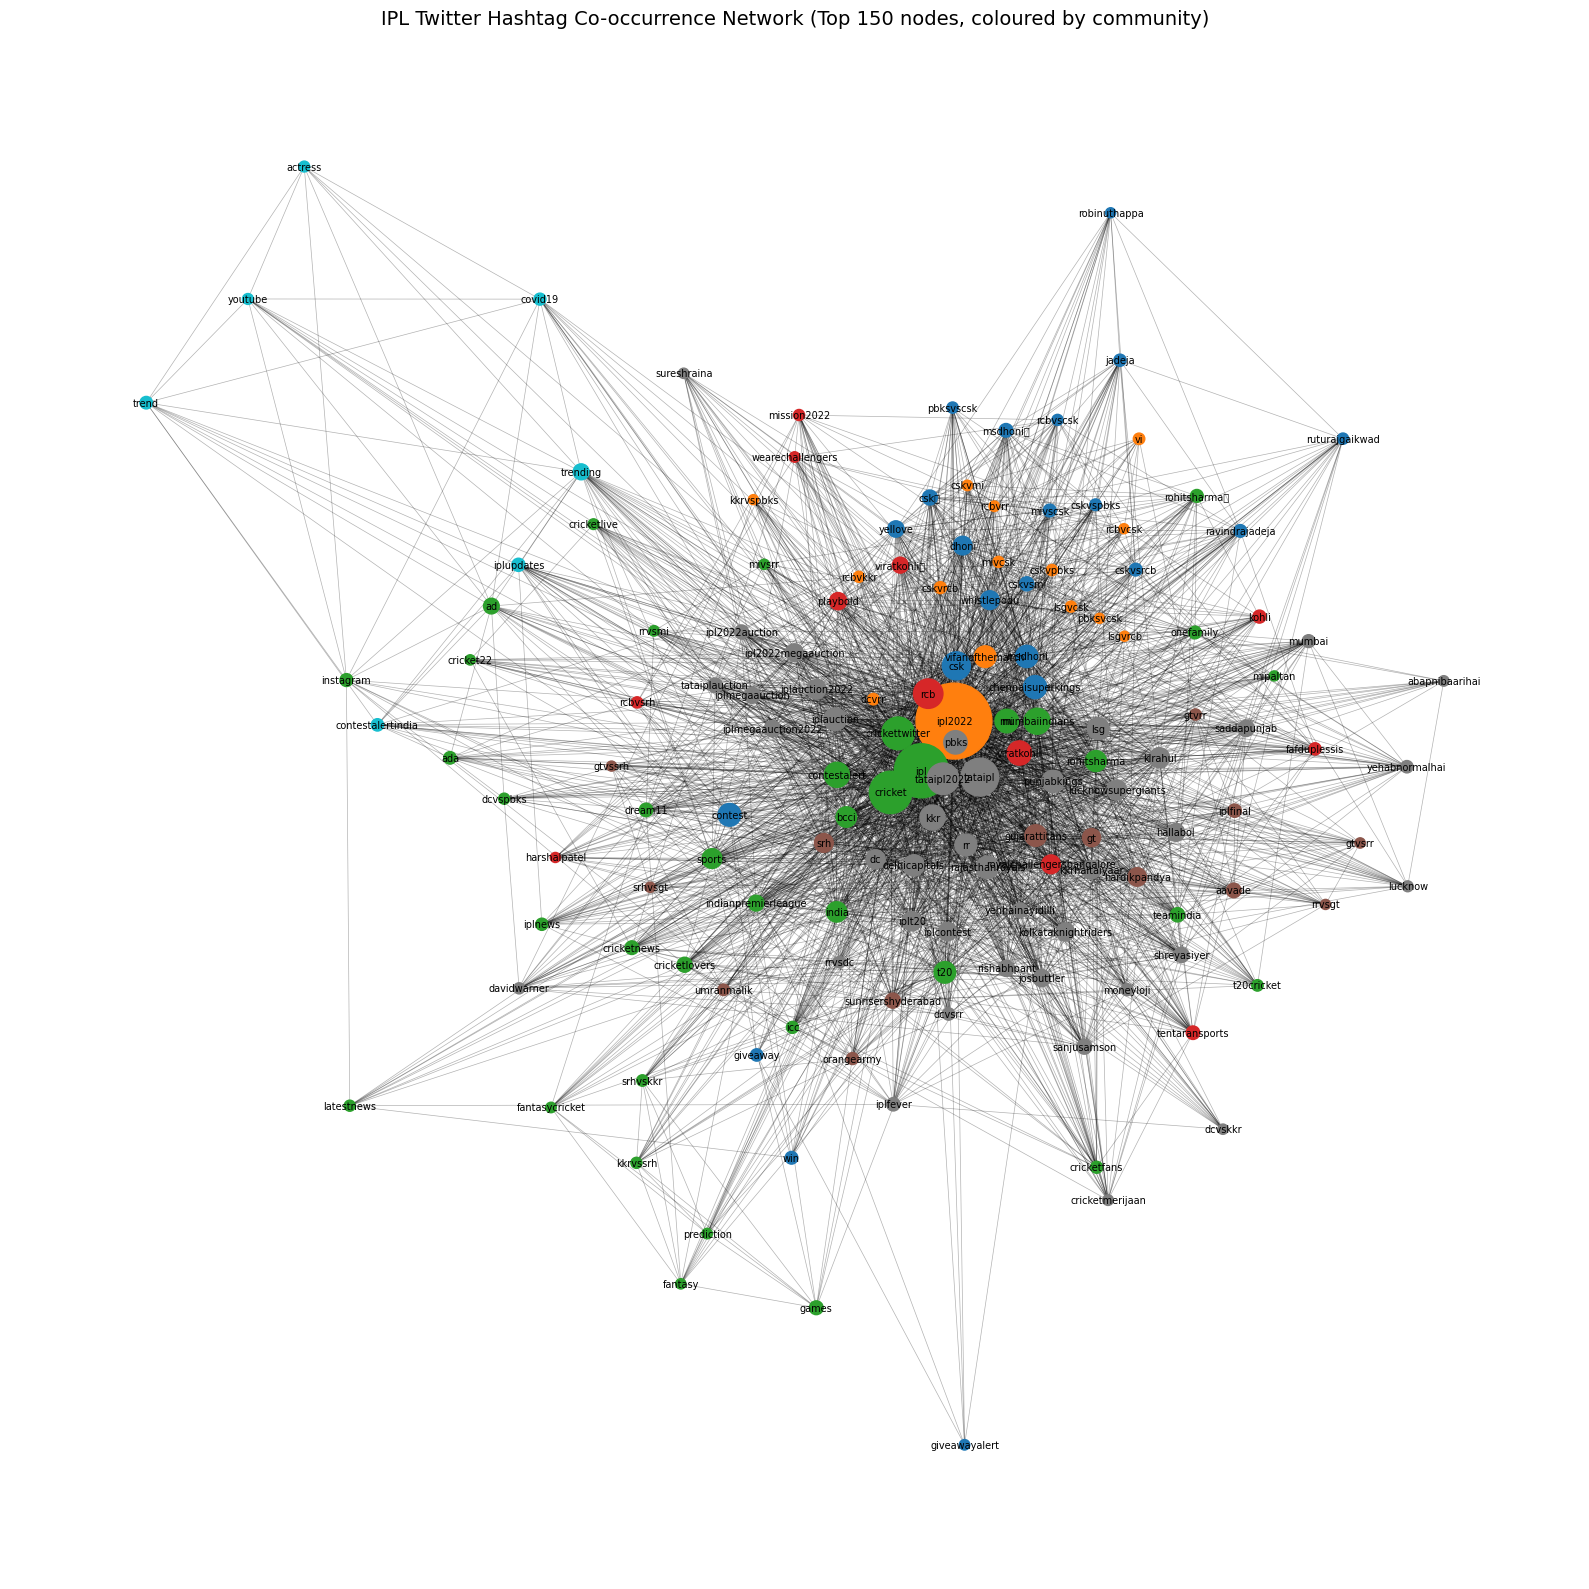

In [8]:
plt.figure(figsize=(16, 16))

top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:150]
top_node_names = [n[0] for n in top_nodes]
subgraph = G.subgraph(top_node_names)

pos = nx.spring_layout(subgraph, k=0.5, seed=42)

colors = [partition[node] for node in subgraph.nodes()]
node_sizes = [degree_centrality[node] * 3000 for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos, node_color=colors, cmap=plt.cm.tab10, node_size=node_sizes)
nx.draw_networkx_labels(subgraph, pos, font_size=7)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, width=0.5)

plt.title("IPL Twitter Hashtag Co-occurrence Network (Top 150 nodes, coloured by community)", fontsize=14)
plt.axis("off")
plt.tight_layout()

plt.show()

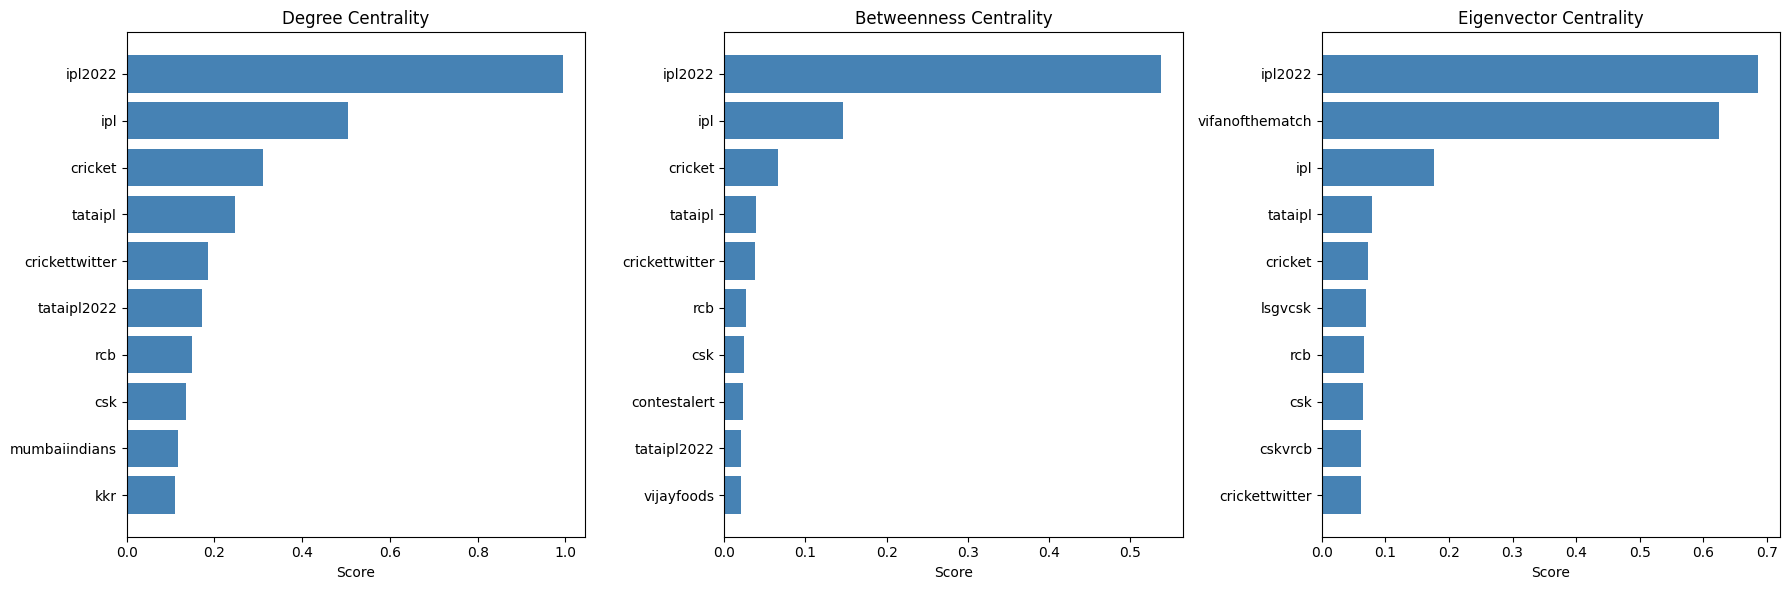

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    (top_degree, "Degree Centrality"),
    (top_between, "Betweenness Centrality"),
    (top_eigen, "Eigenvector Centrality")
]

for ax, (data, title) in zip(axes, metrics):
    nodes, scores = zip(*data)
    ax.barh(nodes[::-1], scores[::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Score")

plt.tight_layout()

plt.show()

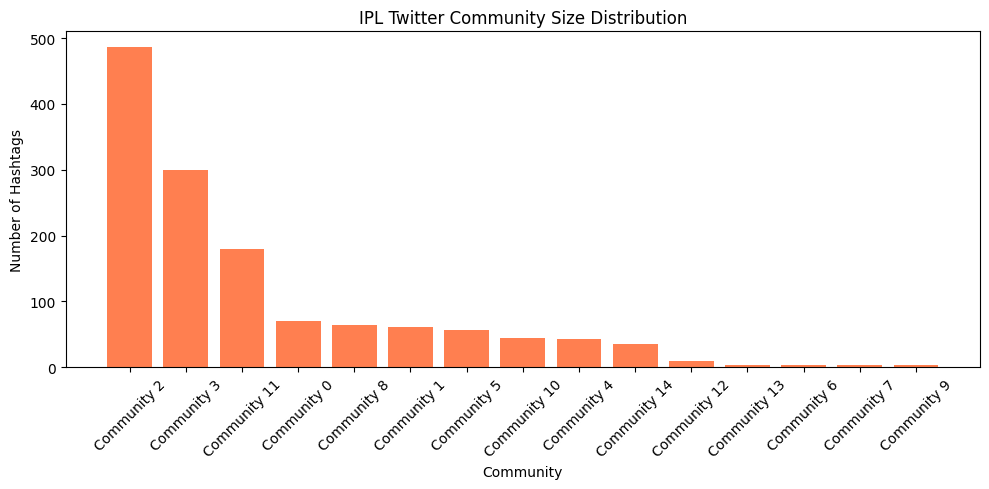

In [10]:
plt.figure(figsize=(10, 5))
comms = sorted(community_counts.items(), key=lambda x: x[1], reverse=True)
labels = [f"Community {c}" for c, _ in comms]
sizes = [s for _, s in comms]

plt.bar(labels, sizes, color="coral")
plt.title("IPL Twitter Community Size Distribution")
plt.xlabel("Community")
plt.ylabel("Number of Hashtags")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
print("NETWORK ANALYSIS SUMMARY")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"Number of communities: {len(community_counts)}")
print(f"Most central hashtag (degree): {top_degree[0][0]}")
print(f"Most central hashtag (betweenness): {top_between[0][0]}")
print(f"Most central hashtag (eigenvector): {top_eigen[0][0]}")
print(f"Largest community: Community {comms[0][0]} with {comms[0][1]} nodes")

NETWORK ANALYSIS SUMMARY
Total nodes: 1364
Total edges: 9691
Number of communities: 15
Most central hashtag (degree): ipl2022
Most central hashtag (betweenness): ipl2022
Most central hashtag (eigenvector): ipl2022
Largest community: Community 2 with 486 nodes
